# Experiments 1 & 2 — LQR v13 Simulation
LQR vs 50:50 Baseline  |  Luenberger observer  |  1.5 hours


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are

A_D = np.array([
    [0.99930577, -0.00002068, -0.00003493],
    [0.00233387,  0.98443635,  0.02453758],
    [-0.00015568,  0.00111512,  0.99805077]
])
B_D = np.array([
    [0.0,          1.80650e-03],
    [6.84417e-04, -4.73295e-03],
    [2.49130e-02, -1.66300e-03],
])
VFA0, EC0, PH0 = 50.25, 10.0, 7.2
x_sp  = np.array([VFA0, EC0, PH0])
u_bl  = np.array([0.050637, 0.050637])
D_OFF = (np.eye(3) - A_D) @ x_sp - B_D @ u_bl

Q_lqr  = np.diag([0.01, 0.01, 1000.0])
R_lqr  = np.diag([0.01, 0.0001])
P_dare = solve_discrete_are(A_D, B_D, Q_lqr, R_lqr)
K      = np.linalg.inv(R_lqr + B_D.T @ P_dare @ B_D) @ (B_D.T @ P_dare @ A_D)

L_GAIN = np.array([
    [0.069052, -0.012473],
    [0.086008,  0.010409],
    [0.010409,  0.092932]
])

U_MIN = 0.050637; U_MAX_URI = 1.855*45; U_MAX_AJ = 1.055*45; U_BASE = U_MIN
N = 90  # 1.5 hours
PRE_STEPS = 10
pre_t   = np.linspace(-PRE_STEPS/60, 0, PRE_STEPS)
pre_pH  = np.linspace(7.8, 6.5, PRE_STEPS)

def prepend(hist, key):
    if key=='pH':    pre = pre_pH
    elif key=='EC':  pre = np.linspace(EC0+2, EC0, PRE_STEPS)
    elif key=='VFA': pre = np.full(PRE_STEPS, VFA0)
    elif key=='frac':pre = np.full(PRE_STEPS, 0.5)
    else:            pre = np.zeros(PRE_STEPS)
    return np.concatenate([pre_t, np.arange(N)/60.0]), np.concatenate([pre, hist[key]])

def run_sim(use_lqr, lqr_log=None):
    x = np.array([VFA0, EC0, 6.5]); x_obs = x.copy()
    hist = {k:[] for k in ['pH','EC','VFA','u_uri','u_AJ','total','frac']}
    fl = []
    for step in range(N):
        if use_lqr:
            dx  = np.array([x_obs[0]-VFA0, x[1]-EC0, x[2]-PH0])
            raw = np.array([U_BASE, U_BASE]) - K @ dx
            u   = np.array([np.clip(raw[0], U_MIN, U_MAX_URI), np.clip(raw[1], U_MIN, U_MAX_AJ)])
            fl.append(u.sum())
        else:
            total = lqr_log[step] if step < len(lqr_log) else lqr_log[-1]
            u = np.array([np.clip(total/2, U_MIN, U_MAX_URI), np.clip(total/2, U_MIN, U_MAX_AJ)])
        for _ in range(12):
            x = A_D @ (x - x_sp) + x_sp + B_D @ (u/12) + D_OFF
        innov = np.array([x[1] - x_obs[1], x[2] - x_obs[2]])
        xp    = A_D @ (x_obs - x_sp) + x_sp + B_D @ (u/12) + D_OFF
        x_obs = xp + L_GAIN @ innov
        x_obs[0] = np.clip(x_obs[0], 50.05, 52.0)
        frac = u[0]/u.sum() if u.sum()>0 else 0.5
        for key, val in zip(['pH','EC','VFA','u_uri','u_AJ','total','frac'],
                            [x[2],x[1],x[0],u[0],u[1],u.sum(),frac]):
            hist[key].append(val)
    return hist, fl

lqr_hist, flow_log = run_sim(True)
bl_hist,  _        = run_sim(False, lqr_log=flow_log)
print(f'Exp1 LQR final pH={lqr_hist["pH"][-1]:.3f}')
print(f'Exp2 Baseline final pH={bl_hist["pH"][-1]:.3f}')


Exp1 LQR final pH=7.124
Exp2 Baseline final pH=7.829


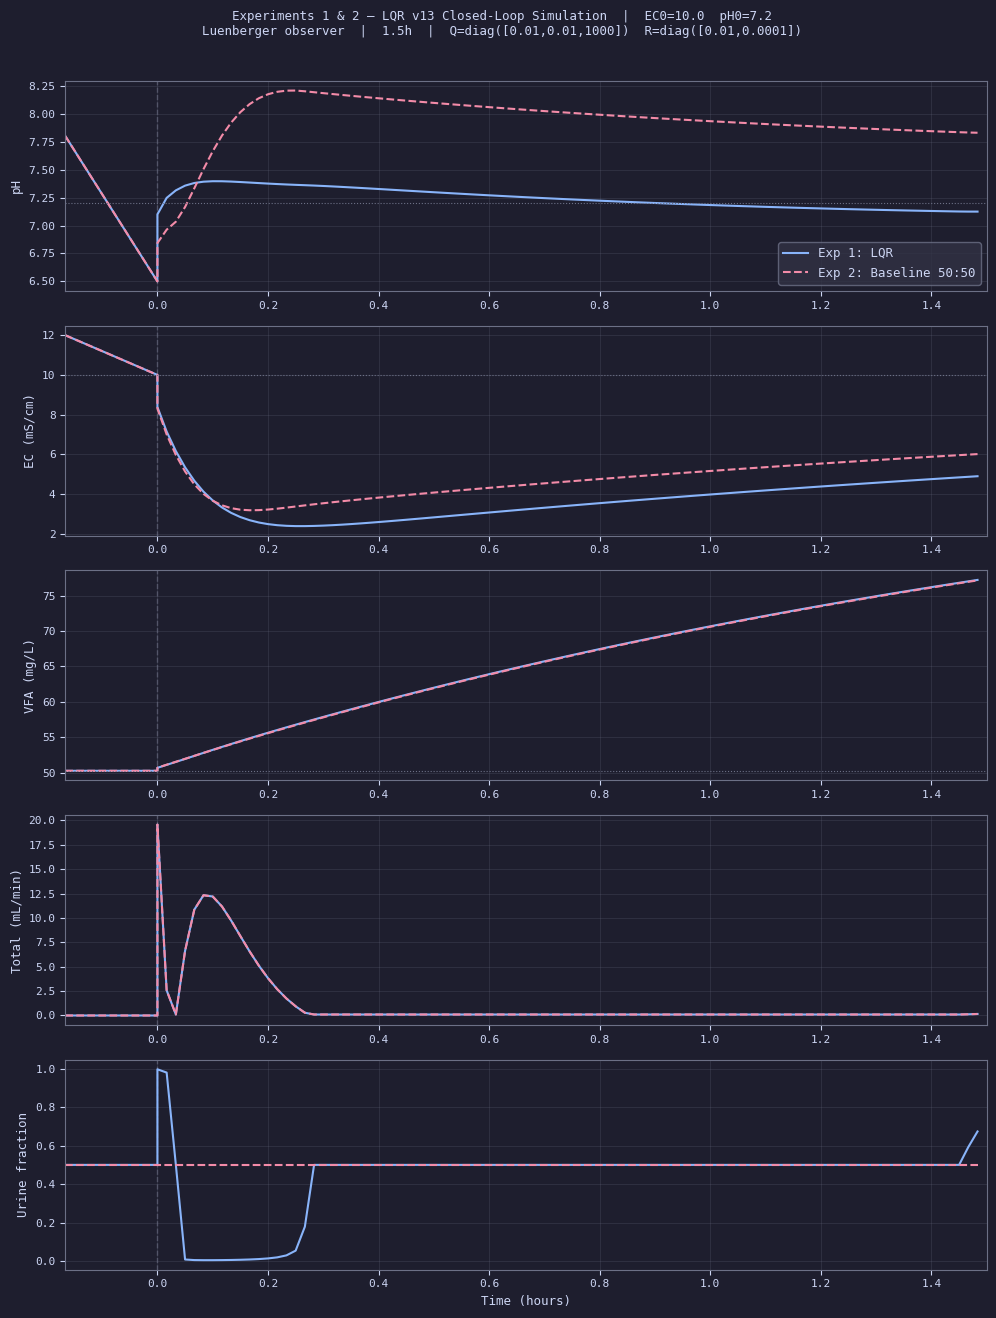

Saved: experiments_1_2_sim.png


In [2]:
BLUE='#89b4fa'; RED='#f38ba8'; GREY='#6c7086'; TEXT='#cdd6f4'
matplotlib.rcParams.update({
    'figure.facecolor':'#1e1e2e','axes.facecolor':'#1e1e2e',
    'text.color':TEXT,'axes.labelcolor':TEXT,
    'xtick.color':TEXT,'ytick.color':TEXT,
    'grid.color':GREY,'grid.linewidth':0.5,'font.family':'monospace'
})

panels = [('pH','pH',PH0),('EC','EC (mS/cm)',EC0),
          ('VFA','VFA (mg/L)',VFA0),('total','Total (mL/min)',None),('frac','Urine fraction',None)]

fig, axes = plt.subplots(5, 1, figsize=(10,13), facecolor='#1e1e2e')
fig.suptitle(
    'Experiments 1 & 2 — LQR v13 Closed-Loop Simulation  |  EC0=10.0  pH0=7.2\n'
    'Luenberger observer  |  1.5h  |  Q=diag([0.01,0.01,1000])  R=diag([0.01,0.0001])',
    color=TEXT, fontsize=9, y=1.01)

for row, (key, ylabel, setpt) in enumerate(panels):
    t1, y1 = prepend(lqr_hist, key)
    t2, y2 = prepend(bl_hist,  key)
    ax = axes[row]; ax.set_facecolor('#1e1e2e')
    for sp in ax.spines.values(): sp.set_color(GREY)
    ax.axvline(0, color=GREY, lw=1.0, linestyle='--', alpha=0.6)
    ax.plot(t1, y1, color=BLUE, lw=1.5, label='Exp 1: LQR')
    ax.plot(t2, y2, color=RED,  lw=1.5, linestyle='--', label='Exp 2: Baseline 50:50')
    if setpt is not None: ax.axhline(setpt, color=GREY, lw=0.8, linestyle=':')
    ax.set_xlim(-PRE_STEPS/60, 1.5); ax.set_ylabel(ylabel, color=TEXT, fontsize=9)
    ax.grid(True, color=GREY, alpha=0.3); ax.tick_params(colors=TEXT, labelsize=8)
    if row==0: ax.legend(fontsize=9, facecolor='#313244', edgecolor=GREY, labelcolor=TEXT)

axes[-1].set_xlabel('Time (hours)', color=TEXT, fontsize=9)
plt.tight_layout()
plt.savefig('experiments_1_2_sim.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('Saved: experiments_1_2_sim.png')
